<a href="https://colab.research.google.com/github/PPRRAATTIIKK/ChatBot/blob/main/medical_chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Medical Assistant Chatbot
### NLP Chatbot using LSTM + TensorFlow/Keras on custom Intents

This notebook builds a **sequence-to-intent chatbot** for a medical assistant system.  
The bot handles greetings, adverse drug reactions, blood pressure tracking, pharmacy/hospital search, and more.

**Architecture:** Token Embedding → LSTM → Flatten → Softmax  
**Training data:** `intents.json` — 13 intent categories with pattern–response pairs

---
## 1. Install & Import Libraries

In [3]:
# Install if running on Colab
# !pip install tensorflow numpy pandas scikit-learn matplotlib

In [4]:
import json
import string
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder

print(f'✅  TensorFlow  : {tf.__version__}')
print(f'✅  NumPy       : {np.__version__}')
print(f'✅  Pandas      : {pd.__version__}')

✅  TensorFlow  : 2.20.0
✅  NumPy       : 2.0.2
✅  Pandas      : 2.2.2


---
## 2. Load Intents Data

In [5]:
# ── For Google Colab: upload intents.json ──────────────────────────────────
# from google.colab import files
# uploaded = files.upload()   # select intents.json
# ──────────────────────────────────────────────────────────────────────────

with open('/content/intents.json') as f:
    raw_data = json.load(f)

print(f'Loaded {len(raw_data["intents"])} intent categories')
print('Tags found:', [i['tag'] for i in raw_data['intents']])

Loaded 14 intent categories
Tags found: ['greeting', 'goodbye', 'thanks', 'noanswer', 'options', 'adverse_drug', 'blood_pressure', 'blood_pressure_search', 'search_blood_pressure_by_patient_id', 'pharmacy_search', 'search_pharmacy_by_name', 'hospital_search', 'search_hospital_by_params', 'search_hospital_by_type']


---
## 3. Parse Intents into DataFrame

In [6]:
tags      = []
patterns  = []
responses = {}     # tag → list of responses
contexts  = {}     # tag → context for multi-turn flows

for intent in raw_data['intents']:
    responses[intent['tag']] = intent['responses']
    contexts[intent['tag']]  = intent.get('context', [''])
    for pattern in intent['patterns']:
        patterns.append(pattern)
        tags.append(intent['tag'])

df = pd.DataFrame({'patterns': patterns, 'tags': tags})

print(f'Total training patterns : {len(df)}')
print(f'Unique intent tags      : {df["tags"].nunique()}')
print()
df.head(10)

Total training patterns : 47
Unique intent tags      : 9



,patterns,tags
0,Hi there,greeting
1,How are you,greeting
2,Is anyone there?,greeting
3,Hey,greeting
4,Hola,greeting
5,Hello,greeting
6,Good day,greeting
7,Bye,goodbye
8,See you later,goodbye
9,Goodbye,goodbye


In [7]:
# Pattern count per tag
print('Patterns per intent tag:')
print('-' * 40)
print(df['tags'].value_counts().to_string())

Patterns per intent tag:
----------------------------------------
tags
greeting                 7
goodbye                  5
thanks                   5
options                  5
adverse_drug             5
blood_pressure           5
blood_pressure_search    5
pharmacy_search          5
hospital_search          5


---
## 4. Text Preprocessing

- Lowercase all characters
- Remove punctuation

In [8]:
def clean_text(text: str) -> str:
    """Lowercase and strip punctuation from a pattern string."""
    return ''.join(ch.lower() for ch in text if ch not in string.punctuation)

df['patterns'] = df['patterns'].apply(clean_text)

print('Sample cleaned patterns:')
print(df[['patterns','tags']].head(10).to_string(index=False))

Sample cleaned patterns:
       patterns     tags
       hi there greeting
    how are you greeting
is anyone there greeting
            hey greeting
           hola greeting
          hello greeting
       good day greeting
            bye  goodbye
  see you later  goodbye
        goodbye  goodbye


---
## 5. Tokenisation & Sequence Padding

In [9]:
VOCAB_SIZE = 2000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['patterns'])

sequences = tokenizer.texts_to_sequences(df['patterns'])
x_train   = pad_sequences(sequences)

input_shape = x_train.shape[1]
vocab_size  = len(tokenizer.word_index)

print(f'Vocabulary size    : {vocab_size} unique words')
print(f'Input shape        : {x_train.shape}  (samples × padded_length)')
print(f'Max sequence length: {input_shape}')

Vocabulary size    : 90 unique words
Input shape        : (47, 9)  (samples × padded_length)
Max sequence length: 9


---
## 6. Label Encoding

In [10]:
le = LabelEncoder()
y_train = le.fit_transform(df['tags'])

output_classes = len(le.classes_)

print(f'Output classes: {output_classes}')
print('Encoding map:')
for tag, idx in zip(le.classes_, range(output_classes)):
    print(f'  {idx:2d} → {tag}')

Output classes: 9
Encoding map:
   0 → adverse_drug
   1 → blood_pressure
   2 → blood_pressure_search
   3 → goodbye
   4 → greeting
   5 → hospital_search
   6 → options
   7 → pharmacy_search
   8 → thanks


---
## 7. Build the LSTM Model

```
Input (padded sequence)
     │
Embedding (vocab+1 → 10 dims)
     │
LSTM (10 units, return_sequences=True)
     │
Flatten
     │
Dense (output_classes, softmax)
```

In [11]:
tf.random.set_seed(42)

inp = Input(shape=(input_shape,))
x   = Embedding(vocab_size + 1, 10)(inp)
x   = LSTM(10, return_sequences=True)(x)
x   = Flatten()(x)
out = Dense(output_classes, activation='softmax')(x)

model = Model(inp, out)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 9, 10)          │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 9, 10)          │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 90)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │           819 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,569 (10.04 KB)

 Trainable params: 2,569 (10.04 KB)

 Non-trainable params: 0 (0.00 B)

---
## 8. Train the Model

In [12]:
EPOCHS    = 200
BATCH     = 8

early_stop = EarlyStopping(
    monitor='accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=[early_stop],
    verbose=1
)

final_acc  = history.history['accuracy'][-1]
final_loss = history.history['loss'][-1]
print(f'\n✅  Training complete!')
print(f'   Final accuracy : {final_acc:.4f} ({final_acc*100:.2f}%)')
print(f'   Final loss     : {final_loss:.4f}')

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0638 - loss: 2.1980
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1915 - loss: 2.1935 
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2128 - loss: 2.1903 
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2340 - loss: 2.1869 
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2340 - loss: 2.1832 
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2128 - loss: 2.1788     
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2128 - loss: 2.1736     
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2128 - loss: 2.1673     
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2128 - loss: 2.1597     
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2128 - loss: 2.1503    
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2128 - loss: 2.1387     
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

---
## 9. Training Curves

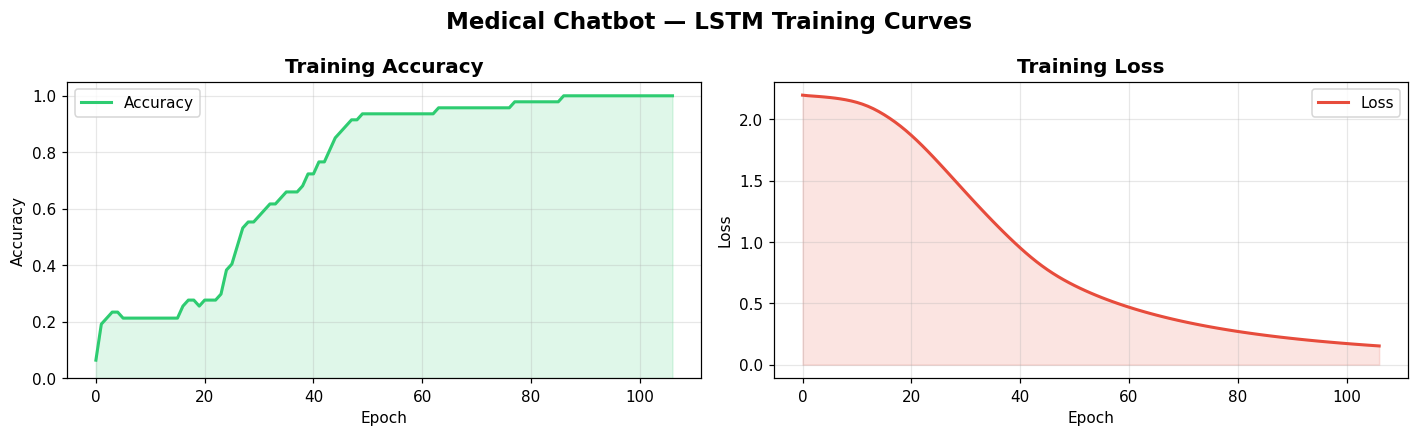

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=110)

# Accuracy
axes[0].plot(history.history['accuracy'], color='#2ecc71', linewidth=2, label='Accuracy')
axes[0].fill_between(range(len(history.history['accuracy'])),
                     history.history['accuracy'], alpha=0.15, color='#2ecc71')
axes[0].set_title('Training Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], color='#e74c3c', linewidth=2, label='Loss')
axes[1].fill_between(range(len(history.history['loss'])),
                     history.history['loss'], alpha=0.15, color='#e74c3c')
axes[1].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('Medical Chatbot — LSTM Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Save the Model & Artefacts

In [14]:
import pickle

model.save('medical_chatbot_model.h5')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('✅  Saved:')
print('   • medical_chatbot_model.h5')
print('   • tokenizer.pkl')
print('   • label_encoder.pkl')

✅  Saved:
   • medical_chatbot_model.h5
   • tokenizer.pkl
   • label_encoder.pkl


---
## 11. Inference Helper Function

In [15]:
def predict_intent(text: str, threshold: float = 0.3) -> str:
    """Predict the intent tag for a user message."""
    cleaned = ''.join(ch.lower() for ch in text if ch not in string.punctuation)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=input_shape)
    probs   = model.predict(padded, verbose=0)[0]
    idx     = np.argmax(probs)
    if probs[idx] < threshold:
        return 'noanswer'
    return le.inverse_transform([idx])[0]


def get_response(intent_tag: str) -> str:
    """Return a random response for the predicted intent tag."""
    return random.choice(responses.get(intent_tag, ["I'm not sure I understand."]))


def chat(user_input: str) -> str:
    """Full pipeline: raw user text → bot response string."""
    tag = predict_intent(user_input)
    return f'[Intent: {tag}]  {get_response(tag)}'


print('✅  Inference functions ready!')

✅  Inference functions ready!


---
## 12. Quick Inference Tests

In [16]:
test_inputs = [
    "Hello there!",
    "How can you help me?",
    "Give me a list of drugs causing adverse behavior",
    "I want to log blood pressure results",
    "Find me a pharmacy nearby",
    "I want to search hospital data",
    "Thanks a lot!",
    "Goodbye",
    "What is the weather today?",   # out-of-scope → noanswer
]

print('Medical Chatbot — Inference Tests')
print('=' * 65)
for inp in test_inputs:
    tag  = predict_intent(inp)
    resp = get_response(tag)
    print(f'  USER : {inp}')
    print(f'  BOT  : {resp}')
    print(f'  TAG  : [{tag}]')
    print('-' * 65)

Medical Chatbot — Inference Tests
  USER : Hello there!
  BOT  : Good to see you again
  TAG  : [greeting]
-----------------------------------------------------------------
  USER : How can you help me?
  BOT  : I can guide you through Adverse drug reaction list, Blood pressure tracking, Hospitals and Pharmacies
  TAG  : [options]
-----------------------------------------------------------------
  USER : Give me a list of drugs causing adverse behavior
  BOT  : Navigating to Adverse drug reaction module
  TAG  : [adverse_drug]
-----------------------------------------------------------------
  USER : I want to log blood pressure results
  BOT  : Navigating to Blood Pressure module
  TAG  : [blood_pressure]
-----------------------------------------------------------------
  USER : Find me a pharmacy nearby
  BOT  : Please provide pharmacy name
  TAG  : [pharmacy_search]
-----------------------------------------------------------------
  USER : I want to search hospital data
  BOT  : Ple

---
## 13. Interactive Chat Loop

> Type your message and press Enter. Type `quit` or `exit` to stop.

In [ ]:
print('🏥 Medical Assistant Chatbot')
print('   Type "quit" to exit')
print('=' * 50)

context_state = ''

while True:
    try:
        user_msg = input('You  >> ').strip()
    except (EOFError, KeyboardInterrupt):
        print('\n[Session ended]')
        break

    if not user_msg:
        continue
    if user_msg.lower() in ('quit', 'exit', 'bye'):
        print('Bot  >> Goodbye! Stay healthy. 👋')
        break

    # Multi-turn context: if we're waiting for a follow-up, use that tag
    if context_state:
        tag  = context_state
        resp = get_response(tag)
        next_ctx = contexts.get(tag, [''])[0]
        context_state = next_ctx
    else:
        tag  = predict_intent(user_msg)
        resp = get_response(tag)
        next_ctx = contexts.get(tag, [''])[0]
        if next_ctx:
            context_state = next_ctx

    print(f'Bot  >> {resp}')
    print(f'       [intent: {tag}]')

🏥 Medical Assistant Chatbot
   Type "quit" to exit
You  >> hi
Bot  >> Good to see you again
       [intent: greeting]


---
## 14. Intent Distribution Visualisation

In [ ]:
tag_counts = df['tags'].value_counts()

colors = plt.cm.Set3(np.linspace(0, 1, len(tag_counts)))

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
bars = ax.barh(tag_counts.index, tag_counts.values,
               color=colors, edgecolor='white', height=0.65)

for bar, val in zip(bars, tag_counts.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val} patterns', va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, tag_counts.max() + 2)
ax.set_xlabel('Number of Training Patterns', fontsize=11)
ax.set_title('Training Patterns per Intent Tag', fontsize=13, fontweight='bold', pad=12)
ax.xaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('intent_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal patterns: {len(df)}')
print(f'Tags with 0 patterns (context-only): {sum(tag_counts == 0)}')

---
## Summary

| Component | Detail |
|---|---|
| **Model** | Embedding → LSTM → Flatten → Dense (Softmax) |
| **Vocabulary** | Up to 2,000 tokens |
| **Intent classes** | 13 (greeting, adverse_drug, blood_pressure, pharmacy_search, …) |
| **Multi-turn** | Context-based follow-up supported (pharmacy/hospital/blood pressure search) |
| **Saved artefacts** | `medical_chatbot_model.h5`, `tokenizer.pkl`, `label_encoder.pkl` |

**To extend:** add more patterns to `intents.json` and re-run from Cell 2 onwards — no architecture changes needed.